# Practical Ensemble Methods: Random Forest & Boosting

Welcome to this practical guide on Ensemble Methods! In this notebook, we will explore how to build, evaluate, and compare Random Forests and Boosting algorithms using `scikit-learn` and `xgboost`. We'll also dive deep into the theory behind bagging and boosting, and compare them with simple decision trees.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn modules
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# XGBoost
import xgboost as xgb

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Introduction to Ensemble Methods

Ensemble methods combine multiple machine learning models to create a more powerful predictive model. The key insight is that **combining diverse models often produces better results than any single model alone**. This is known as the **wisdom of crowds** principle in machine learning.

### Why Ensemble Methods Work

1. **Variance Reduction:** Multiple models reduce the variance of predictions
2. **Bias Reduction:** Different models can compensate for each other's biases
3. **Robustness:** Ensemble methods are less sensitive to outliers and noise
4. **Better Generalization:** They typically generalize better to unseen data

### Two Main Paradigms

**Bagging (Bootstrap Aggregating):** Builds multiple independent models on different random subsets of the training data and averages their predictions. Random Forest is the most popular bagging algorithm.

**Boosting:** Builds models sequentially, where each new model tries to correct the errors made by the previous ones. Examples include AdaBoost, Gradient Boosting, and XGBoost.

## 2. Understanding Bagging (Bootstrap Aggregating)

### What is Bagging?

Bagging is an ensemble technique that reduces variance by training multiple models on different subsets of the training data. Here's how it works:

1. **Bootstrap Sampling:** Randomly sample the training data *with replacement* to create multiple datasets of the same size as the original
2. **Train Models:** Train a separate model (usually decision trees) on each bootstrap sample
3. **Aggregate Predictions:** 
   - For classification: Use majority voting
   - For regression: Use averaging

### Why Bootstrap Sampling?

Bootstrap sampling creates diversity among the training sets. Each bootstrap sample is slightly different, so each model learns slightly different patterns. This diversity is crucial for ensemble methods to work well.

### Key Advantages of Bagging

- **Reduces Overfitting:** By averaging predictions from multiple models, bagging reduces the variance and thus overfitting
- **Parallelizable:** Since models are trained independently, bagging can be easily parallelized
- **Works with High-Variance Models:** Bagging is particularly effective with high-variance models like deep decision trees
- **Out-of-Bag (OOB) Error:** Can estimate generalization error without a separate validation set

### Mathematical Intuition

If we have n independent models with error variance σ², the variance of the ensemble average is σ²/n. This shows that as we add more models, the variance decreases!

### Random Forest: Bagging with a Twist

Random Forest enhances bagging by:
1. Using bootstrap samples (like bagging)
2. **Adding randomness to feature selection:** At each split, only a random subset of features is considered
3. This extra randomness further reduces correlation between trees, making the ensemble even more effective

## 3. Data Preparation

We will use the **Wine dataset** for classification to compare these algorithms.

In [2]:
# Load dataset
wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = wine_data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {wine_data.target_names}")
print(f"\nFeature names:")
for i, name in enumerate(wine_data.feature_names):
    print(f"  {i+1}. {name}")

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']

Feature names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Training samples: 142
Testing samples: 36


## 4. Decision Tree vs. Random Forest: A Practical Comparison

Let's first train a simple decision tree and compare it with a Random Forest to see the power of ensemble methods.

Decision Tree Accuracy: 0.9444
Random Forest Accuracy: 1.0000
Improvement: 0.0556 (5.88%)

Decision Tree - Train: 1.0000, Test: 0.9444, Overfitting Gap: 0.0556
Random Forest - Train: 1.0000, Test: 1.0000, Overfitting Gap: 0.0000


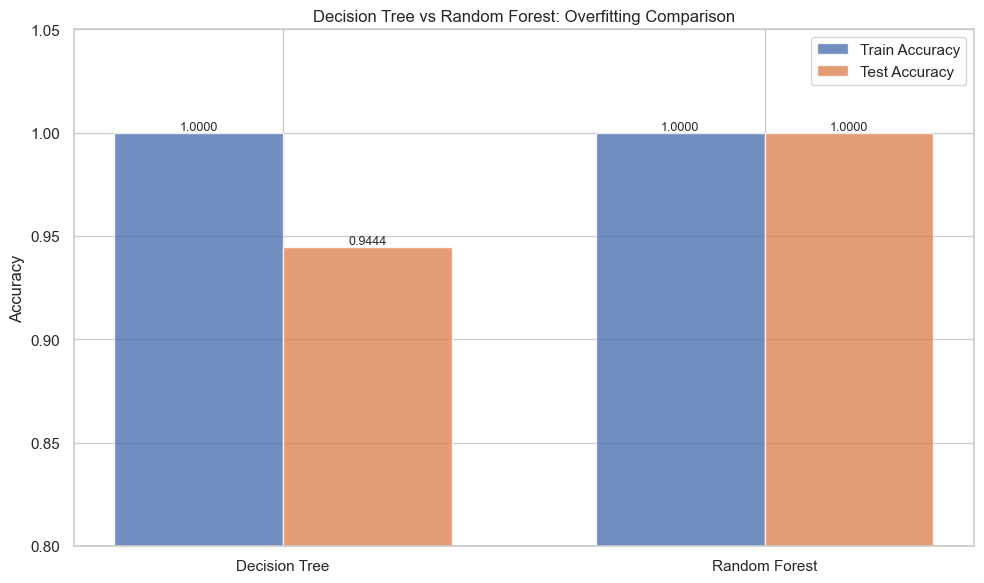

In [3]:
# Train a simple Decision Tree
dt_simple = DecisionTreeClassifier(random_state=42)
dt_simple.fit(X_train, y_train)
y_pred_dt = dt_simple.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

# Train Random Forest with default parameters
rf_simple = RandomForestClassifier(n_estimators=100, random_state=42)
rf_simple.fit(X_train, y_train)
y_pred_rf = rf_simple.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Improvement: {(rf_acc - dt_acc):.4f} ({((rf_acc - dt_acc) / dt_acc * 100):.2f}%)")

# Compare training vs test accuracy to see overfitting
dt_train_acc = accuracy_score(y_train, dt_simple.predict(X_train))
rf_train_acc = accuracy_score(y_train, rf_simple.predict(X_train))

print(f"\nDecision Tree - Train: {dt_train_acc:.4f}, Test: {dt_acc:.4f}, Overfitting Gap: {(dt_train_acc - dt_acc):.4f}")
print(f"Random Forest - Train: {rf_train_acc:.4f}, Test: {rf_acc:.4f}, Overfitting Gap: {(rf_train_acc - rf_acc):.4f}")

# Visualize comparison
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Train Accuracy': [dt_train_acc, rf_train_acc],
    'Test Accuracy': [dt_acc, rf_acc]
})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Train Accuracy'], width, label='Train Accuracy', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8)

ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree vs Random Forest: Overfitting Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0.8, 1.05])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Random Forest: Detailed Analysis with GridSearchCV

Now let's dive deeper into Random Forest and use GridSearchCV to find optimal hyperparameters.

In [4]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
print("Running GridSearchCV for Random Forest...")
print("This may take a minute...")
grid_search_rf.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Score: {grid_search_rf.best_score_:.4f}")

# Evaluate best model
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
best_rf_acc = accuracy_score(y_test, y_pred_best_rf)

print(f"\nBest Random Forest Test Accuracy: {best_rf_acc:.4f}")
print(f"Improvement over default RF: {(best_rf_acc - rf_acc):.4f}")

Running GridSearchCV for Random Forest...
This may take a minute...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.9862

Best Random Forest Test Accuracy: 1.0000
Improvement over default RF: 0.0000


In [ ]:
# Create a DataFrame of GridSearch results
results_df = pd.DataFrame(grid_search_rf.cv_results_)
results_df = results_df[['param_max_depth', 'param_n_estimators', 'param_min_samples_split', 'mean_test_score']].sort_values('mean_test_score', ascending=False)

print("Top 10 Parameter Combinations:")
print(results_df.head(10).to_string())

# Visualize the impact of key parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Impact of max_depth
depth_results = results_df.groupby('param_max_depth')['mean_test_score'].mean()
axes[0].plot(depth_results.index.astype(str), depth_results.values, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Mean CV Accuracy')
axes[0].set_title('Impact of max_depth on Random Forest Performance')
axes[0].grid(True, alpha=0.3)

# Impact of n_estimators
n_est_results = results_df.groupby('param_n_estimators')['mean_test_score'].mean()
axes[1].plot(n_est_results.index, n_est_results.values, marker='s', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Mean CV Accuracy')
axes[1].set_title('Impact of n_estimators on Random Forest Performance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Understanding Boosting Methods

Boosting is fundamentally different from bagging. Instead of training models independently, boosting trains models **sequentially**, where each new model focuses on correcting the errors made by previous models.

### How Boosting Works (General Algorithm)

1. **Train First Model:** Train a weak learner on the original data
2. **Calculate Errors:** Identify which samples were misclassified
3. **Weight Adjustment:** Increase weights on misclassified samples
4. **Train Next Model:** Train the next weak learner on the weighted data
5. **Repeat:** Continue until desired number of models or convergence
6. **Combine:** Combine all models using weighted voting or averaging

### Key Differences: Bagging vs. Boosting

| Aspect | Bagging | Boosting |
|--------|--------|----------|
| **Training** | Parallel, independent | Sequential, dependent |
| **Data Sampling** | Random with replacement | Weighted, focuses on errors |
| **Model Combination** | Simple averaging/voting | Weighted combination |
| **Bias Reduction** | Minimal | Significant |
| **Variance Reduction** | Significant | Minimal |
| **Overfitting Risk** | Lower | Higher (needs regularization) |
| **Computation** | Fast (parallelizable) | Slower (sequential) |

### Boosting Methods Comparison

#### 1. AdaBoost (Adaptive Boosting)

**How It Works:**
- Starts with equal weights for all samples
- After each iteration, increases weights on misclassified samples
- Each weak learner gets a weight based on its accuracy
- Final prediction is a weighted sum of all weak learners

**Strengths:**
- Simple and intuitive
- Works well with weak learners
- Good for binary classification

**Weaknesses:**
- Sensitive to outliers (they get high weights)
- Can overfit with noisy data
- Slower than Random Forest

**Best For:** When you want a simple, interpretable boosting method

#### 2. Gradient Boosting

**How It Works:**
- Builds trees sequentially to minimize a loss function
- Each new tree fits the *residuals* (errors) of the previous trees
- Uses gradient descent to find the best direction to reduce loss
- More flexible: can optimize any differentiable loss function

**Strengths:**
- More powerful than AdaBoost
- Better performance on complex datasets
- Flexible loss functions
- Handles regression and classification well

**Weaknesses:**
- More hyperparameters to tune
- Slower training
- Prone to overfitting (needs careful regularization)

**Best For:** When you need maximum predictive power and have time for hyperparameter tuning

#### 3. XGBoost (Extreme Gradient Boosting)

**How It Works:**
- Optimized implementation of Gradient Boosting
- Includes regularization terms in the loss function
- Uses second-order derivatives (Newton's method)
- Highly optimized for speed and memory efficiency

**Strengths:**
- Fastest gradient boosting implementation
- Built-in regularization prevents overfitting
- Handles missing values
- Excellent performance on competitions (Kaggle)
- Parallel tree boosting

**Weaknesses:**
- More complex to understand
- Many hyperparameters
- Requires more computational resources than simple methods

**Best For:** Production systems, competitions, and when you need the best possible performance

### When to Use Which Boosting Method?

- **AdaBoost:** Quick prototyping, interpretability is important
- **Gradient Boosting:** Good balance of performance and complexity
- **XGBoost:** Maximum performance needed, have time for tuning, working with large datasets

In [5]:
# Initialize AdaBoost
ada_classifier = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_classifier.fit(X_train, y_train)
y_pred_ada = ada_classifier.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

print(f"AdaBoost Accuracy: {ada_acc:.4f}")

# Initialize Gradient Boosting
gb_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_classifier.fit(X_train, y_train)
y_pred_gb = gb_classifier.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")

# Initialize XGBoost
xgb_classifier = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.4f}")

AdaBoost Accuracy: 0.9167
Gradient Boosting Accuracy: 0.9444
XGBoost Accuracy: 1.0000


## 7. Implementing Boosting Methods

Let's implement and compare all three boosting algorithms.


COMPREHENSIVE MODEL COMPARISON
                  Model  Accuracy
Random Forest (Default)  1.000000
  Random Forest (Tuned)  1.000000
                XGBoost  1.000000
          Decision Tree  0.944444
      Gradient Boosting  0.944444
               AdaBoost  0.916667


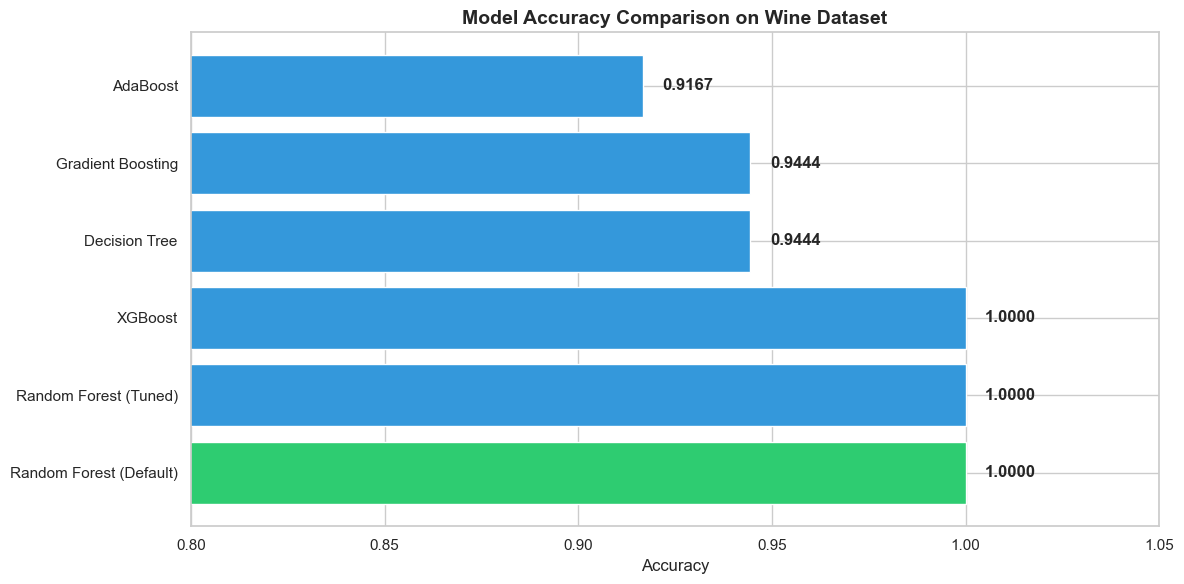

In [7]:
# Comprehensive model comparison
all_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest (Default)', 'Random Forest (Tuned)', 'AdaBoost', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [dt_acc, rf_acc, best_rf_acc, ada_acc, gb_acc, xgb_acc]
})

# Sort by accuracy
all_results = all_results.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)
print(all_results.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(all_results))]
bars = plt.barh(all_results['Model'], all_results['Accuracy'], color=colors)

plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison on Wine Dataset', fontsize=14, fontweight='bold')
plt.xlim([0.8, 1.05])

# Add value labels
for i, (model, acc) in enumerate(zip(all_results['Model'], all_results['Accuracy'])):
    plt.text(acc + 0.005, i, f'{acc:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Comprehensive Model Comparison

Now let's compare all models: Decision Tree, Random Forest, AdaBoost, Gradient Boosting, and XGBoost.


Feature Importance Comparison:
                     Feature  Decision Tree  Random Forest  Gradient Boosting  XGBoost
                  flavanoids       0.408073       0.198813           0.291403 0.256339
             color_intensity       0.400189       0.166514           0.311457 0.220617
                     proline       0.110985       0.153792           0.243876 0.202031
                     alcohol       0.000000       0.125408           0.000756 0.014740
od280/od315_of_diluted_wines       0.020986       0.096235           0.011608 0.033515
                         hue       0.000000       0.085715           0.057246 0.049014
                   magnesium       0.000000       0.039557           0.018709 0.091257
               total_phenols       0.000000       0.037139           0.000920 0.021198
                  malic_acid       0.018738       0.032834           0.031838 0.046193
           alcalinity_of_ash       0.020865       0.025269           0.005484 0.006308
           

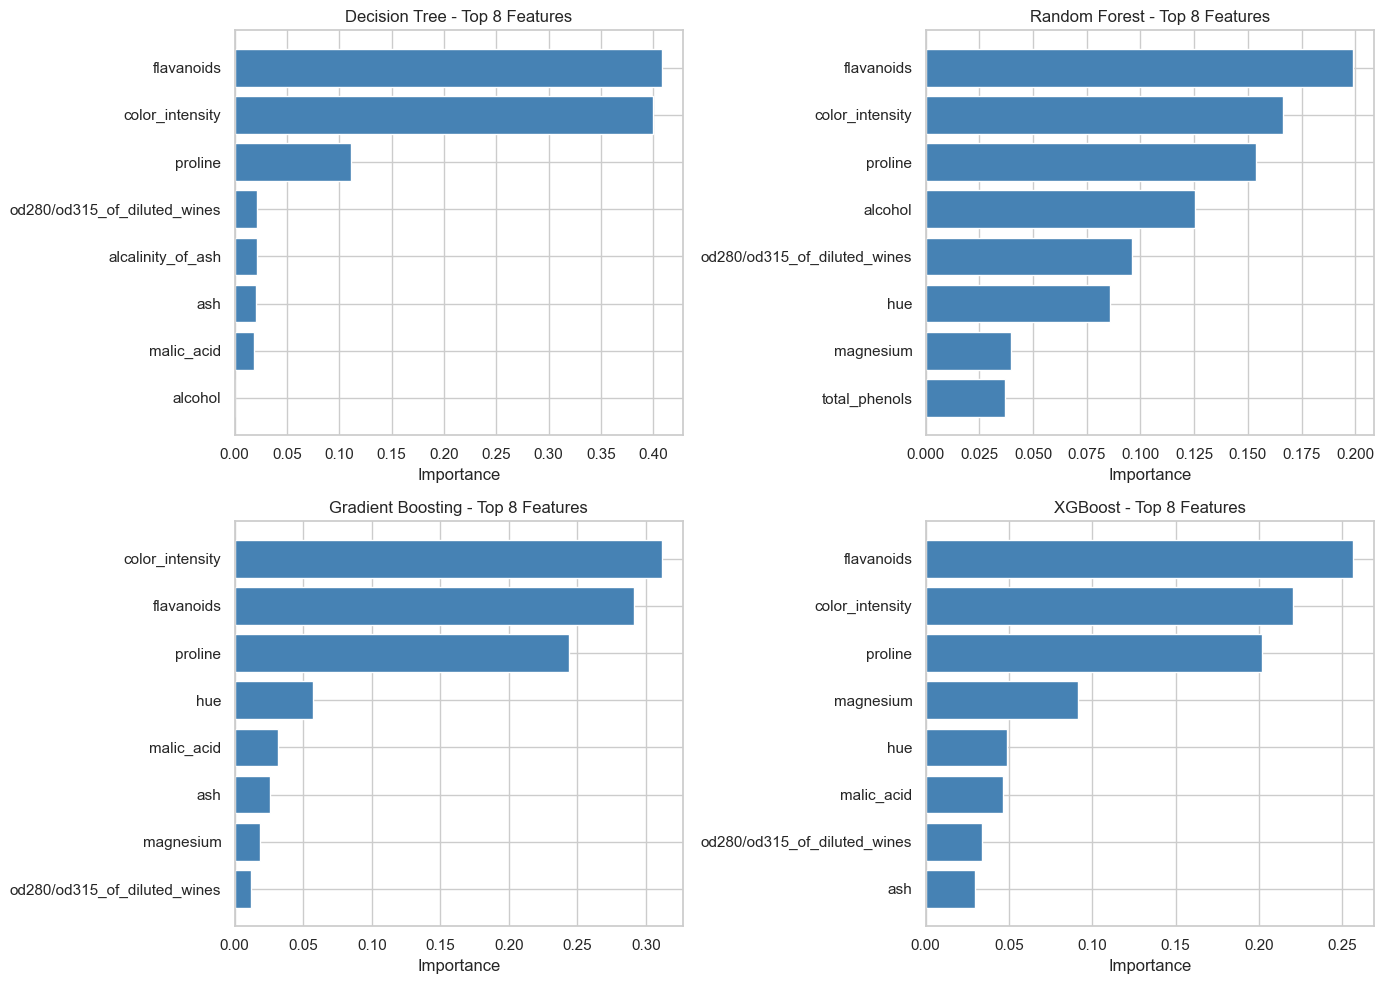

In [ ]:
# Get feature importances from multiple models
feature_names = wine_data.feature_names

# Extract importances
dt_importances = dt_simple.feature_importances_
rf_importances = best_rf.feature_importances_
gb_importances = gb_classifier.feature_importances_
xgb_importances = xgb_classifier.feature_importances_

# Create comparison DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Decision Tree': dt_importances,
    'Random Forest': rf_importances,
    'Gradient Boosting': gb_importances,
    'XGBoost': xgb_importances
})

# Sort by Random Forest importance
feat_imp_df = feat_imp_df.sort_values('Random Forest', ascending=False)

print("\nFeature Importance Comparison:")
print(feat_imp_df.to_string(index=False))

# Visualize feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
axes_flat = axes.flatten()

for idx, (ax, model) in enumerate(zip(axes_flat, models)):
    top_features = feat_imp_df.nlargest(8, model)
    ax.barh(range(len(top_features)), top_features[model].values, color='steelblue')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'].values)
    ax.set_xlabel('Importance')
    ax.set_title(f'{model} - Top 8 Features')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


## 9. Feature Importance Comparison

Let's compare how different algorithms rank feature importance.